## Figure: Agreement and Recource

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    prettify_model_name
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
)

from monoculture.analysis.utils import load_model_outputs_same_prompt, get_metric
from monoculture.analysis.utils import load_task_data

from monoculture.analysis.metrics import observed_agreement_wrapper
from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_barplot,
    plot_recourse_lineplot,
)

In [112]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

In [ ]:
# from seaborn import color_palette
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000', ]
# #color_palette("colorblind")
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

data_all = None

tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Blood_Pressure')


## Load predictions

In [52]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [53]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(set(df_same_prompt["task"].unique()).intersection(TASKS))
TASKS

(238, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Blood_Pressure')

In [54]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_25862/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_25862/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_25862/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

## Restrict analysis to models based on performance or true labels?

In [55]:
restrict_to_better_const = True
restrict_to_top_eps = True
restrict_to_topk = False
topk = 10
eps = 0.05
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()

if data_all:
    data = data_all.copy()
if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data_all:
        logging.warning("Load task data")
        data_all = load_task_data(TASKS, Path("./data"))
        data = data_all.copy()
    elif not all([t in data.keys()for t in TASKS]):
        for t in TASKS:
            if t not in data.keys():
                print(f'add {t} to data')
                data_t =load_task_data(t, Path("./data"))
                data_all.update(data_t)
                data = data_all.copy()


    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            print(const_acc)
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
            data[task] = (data[task][0].loc[filter_idx], data[task][1].loc[filter_idx])
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

evals_per_task = evals_per_task_all.copy()

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

0.6321237608891559
ACSIncome (61233, 40)
0.546554350748275
ACSEmployment (146740, 42)
0.5616882010022841
ACSTravelTime (64285, 19)
0.7015611136002249
ACSPublicCoverage (33971, 12)
0.5265482545231235
BRFSS_Blood_Pressure (44586, 36)
ACSIncome (61233, 21)
ACSEmployment (146740, 7)
ACSTravelTime (64285, 9)
ACSPublicCoverage (33971, 12)
BRFSS_Blood_Pressure (44586, 22)


## Plot

In [56]:
tp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

fp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fpr"]
    for task in TASKS
}

### Agreement in Recourse in One

mean agreement: 0.894939661026001
mean agreement: 0.8820382356643677
mean agreement: 0.7648804187774658
mean agreement: 0.7475711703300476
mean agreement: 0.717131495475769


agreement-recourse-0-shot_tresh_fitted_better_const_pos_instances_eps0_05


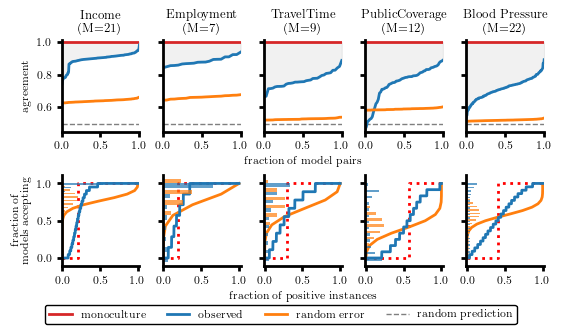

In [73]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

fig, axs = plt.subplots(
    2,
    len(tasks_to_plot),
    #figsize=(4 * len(tasks_to_plot), 6),
    sharey="row",
    constrained_layout=True,
)

sort_by = None
recourse_observed = {}
recourse_at_random = {}
for r in range(2):
    for c, task in enumerate(tasks_to_plot):
        M = predictions[task].shape[1]
        if M > 0:
            models_sorted = sorted(predictions[task].columns, key=get_size_and_it)

            if r == 0:
                # agreements without diagonal
                obs_agreement_matrix = matrix_pairwise_evals(
                    models_sorted,
                    partial(observed_agreement_wrapper, predictions=predictions[task]),
                ).fill_diagonal_(torch.nan)
                exp_agreement_matrix = matrix_pairwise_evals(
                    models_sorted,
                    fun=lambda m1, m2: pairwise_agreement_at_random(
                        evals_per_task[task]["accuracy"][m1],
                        evals_per_task[task]["accuracy"][m2],
                    ),
                ).fill_diagonal_(torch.nan)

                axs[r, c] = plot_agreement_lineplot(
                    axs[r, c],
                    obs_agreement_matrix[~obs_agreement_matrix.isnan()],
                    exp_agreement_matrix[~exp_agreement_matrix.isnan()],
                    #  title="agreement rates",
                    ylim=(0.45, 1.0),
                )
                print(
                    f"mean agreement: {obs_agreement_matrix[~obs_agreement_matrix.isnan()].mean()}"
                )

            elif r == 1:
                axs[r, c], observed, at_random = plot_recourse_lineplot(
                    axs[r, c],
                    predictions=predictions[task],
                    baseline_rates=tp_rates[task].to_list(),
                    y_true=data[task][1],
                    restrict_only_pos_instances=True,
                    restrict_only_neg_instances=False,
                    count_accepted=True,
                    at_least=False,
                    plot_pdf=True,
                    xlabel="",
                    ylabel="",
                    num_ticks=3
                )
                recourse_observed[task] = observed
                recourse_at_random[task] = at_random
        else:
            axs[r, c].set_axis_off()
        if r == 0:
            axs[r, c].set_title(
                f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')}\n(M={M})"
            )


axs[0, 0].set_ylabel("agreement")
axs[0, len(tasks_to_plot) // 2].set_xlabel("fraction of model pairs")

axs[1, 0].set_ylabel("fraction of\n models accepting")
axs[1, len(tasks_to_plot) // 2].set_xlabel("fraction of positive instances")

# legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))


file_name = "".join(
    [
        f"agreement-recourse-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
)
# for ending in [".png", ".pdf"]:
    # plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    # plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [23]:
print(f"{'task':15}&\tno recourse&limited recourse (majority rejects) & full recourse\\\\")
for task in recourse_observed.keys():
    print(f"{task.replace('_', ' '):15} &\t{recourse_observed[task][recourse_observed[task][:,1] == 0.0][-1][0]:.4f}&\t{recourse_observed[task][recourse_observed[task][:,1] <= 0.5][-1][0]:.4f} &\t{1. - recourse_observed[task][recourse_observed[task][:,1] == 1.0][0][0]:.4f}\\\\")

task           &	no recourse&limited recourse (majority rejects) & full recourse\\
ACSIncome       &	0.0750&	0.2072 &	0.4875\\
ACSEmployment   &	0.0727&	0.1654 &	0.6433\\
BRFSS Blood Pressure &	0.0031&	0.0628 &	0.6254\\


In [20]:
print(f"{'model':15}&\tno recourse & limited recourse (majority rejects) & full recourse\\\\")
for task in recourse_observed.keys():
    print(f"{task:15} &\t{recourse_observed[task][recourse_observed[task][:,1] == 0.0][-1][0]:.4f}&\t{recourse_observed[task][recourse_observed[task][:,1] <= 0.5][-1][0]:.4f} &\t{1. - recourse_observed[task][recourse_observed[task][:,1] == 1.0][0][0]:.4f}\\\\")

model          &	no recourse & limited recourse (majority rejects) & full recourse\\
ACSIncome       &	0.0750&	0.2072 &	0.4875\\
ACSEmployment   &	0.0727&	0.1654 &	0.6433\\
BRFSS_Blood_Pressure &	0.0031&	0.0628 &	0.6254\\


### Agreement

mean agreement: 0.894939661026001
mean agreement: 0.8820382356643677
mean agreement: 0.7648804187774658
mean agreement: 0.7475711703300476
mean agreement: 0.717131495475769
agreement-0-shot_tresh_fitted_better_const_pos_instances_eps0_05


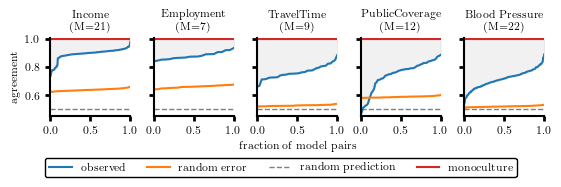

In [120]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']


default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 1.5

fig, axs = plt.subplots(
    1,
    len(tasks_to_plot),
    figsize=(default_width, custom_height),
    sharey="row",
    constrained_layout=True,
)

sort_by = None
recourse_observed = {}
recourse_at_random = {}
for c, task in enumerate(tasks_to_plot):
    M = predictions[task].shape[1]
    if M > 0:
        models_sorted = sorted(predictions[task].columns, key=get_size_and_it)

        # agreements without diagonal
        obs_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            partial(observed_agreement_wrapper, predictions=predictions[task]),
        ).fill_diagonal_(torch.nan)
        exp_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            fun=lambda m1, m2: pairwise_agreement_at_random(
                evals_per_task[task]["accuracy"][m1],
                evals_per_task[task]["accuracy"][m2],
            ),
        ).fill_diagonal_(torch.nan)

        axs[c] = plot_agreement_lineplot(
            axs[c],
            obs_agreement_matrix[~obs_agreement_matrix.isnan()],
            exp_agreement_matrix[~exp_agreement_matrix.isnan()],
            #  title="agreement rates",
            ylim=(0.45, 1.0),
        )
        print(
            f"mean agreement: {obs_agreement_matrix[~obs_agreement_matrix.isnan()].mean()}"
        )
    else:
        axs[c].set_axis_off()
  
    axs[c].set_title(
        f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')}\n(M={M})"
    )


axs[0].set_ylabel("agreement")
axs[len(tasks_to_plot) // 2].set_xlabel("fraction of model pairs")

# legend
desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
handles, labels = axs[0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]
# positioning
# get the bottom-most y-position among all axes
lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])


fig.legend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, lowest_ax_y-0.29),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))


file_name = "".join(
    [
        f"agreement-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

### Recourse

recourse-0-shot_tresh_fitted_better_const_pos_instances_eps0_05


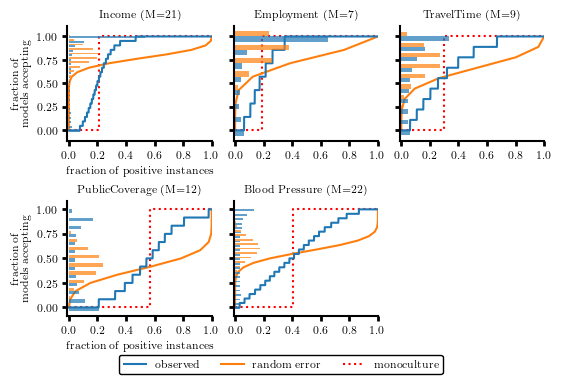

In [125]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 3.5 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    2,
    3,
    figsize=(default_width, custom_height),
    sharey="row",
    constrained_layout=True,
)

sort_by = None
recourse_observed = {}
recourse_at_random = {}
for c, ax in enumerate(axs.flat):
    if c < len(tasks_to_plot):
        task = tasks_to_plot[c]
        M = predictions[task].shape[1]
    else:
        task=""
        M=0
    if M > 0:
        models_sorted = sorted(predictions[task].columns, key=get_size_and_it)

        ax, observed, at_random = plot_recourse_lineplot(
            ax,
            predictions=predictions[task],
            baseline_rates=tp_rates[task].to_list(),
            y_true=data[task][1],
            restrict_only_pos_instances=True,
            restrict_only_neg_instances=False,
            count_accepted=True,
            at_least=False,
            plot_pdf=True,
            xlabel="",
            ylabel="",
            num_ticks=6
        )
        recourse_observed[task] = observed
        recourse_at_random[task] = at_random
    else:
        ax.set_axis_off()
    
    if c < len(tasks_to_plot):
        ax.set_title(
                f"{task.replace('ACS', '').replace('BRFSS', '').replace('_', ' ')} (M={M})"
        )

axs[0, 0].set_ylabel("fraction of\n models accepting")
axs[1, 0].set_ylabel("fraction of\n models accepting")
axs[0, 0].set_xlabel("fraction of positive instances")
axs[1, 0].set_xlabel("fraction of positive instances")

# legend
desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
handles, labels = axs[0, 0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]
# positioning
# get the bottom-most y-position among all axes
lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, lowest_ax_y-0.18),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))


file_name = "".join(
    [
        f"recourse-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

### Overlap Individuals

In [42]:
predictions_all['ACSIncome'].index

Index([ 238351, 2995677, 2360043, 1924596, 2803585, 2784255, 2809101, 1903695,
       3134860,  994065,
       ...
        944636,  675237,  926337, 2205318, 3164791,   43637, 2494279, 2989522,
        688458, 1778641],
      dtype='int64', length=166450)

In [44]:
individuals = []
for t in predictions_all.keys():
    if t.startswith('ACS'):
        print(f"{t}: {predictions_all[t].shape}")
        individuals.append(set(predictions_all[t].index))

ACSIncome: (166450, 48)
ACSEmployment: (323611, 48)
ACSTravelTime: (146665, 22)
ACSPublicCoverage: (113829, 35)
